In [209]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
import os

## Função para ler e juntar os CSV

In [210]:
def load_datasets(folder):

    data_312 = []
    data_41 = []

    for file in os.listdir(folder):
        if file.endswith(".csv"):
            path = os.path.join(folder, file)

            df = pd.read_csv(path)

            if file.endswith("312.csv"):
                data_312.append(df)

            elif file.endswith("41.csv"):
                data_41.append(df)

    df_312 = pd.concat(data_312, ignore_index=True)
    df_41 = pd.concat(data_41, ignore_index=True)

    return df_312, df_41

## Função para adicionar Logos

In [211]:
LOGO_PATHS = {
    "C": "images/C_Logo.png",
    "Python": "images/Python_Logo.png",
    "JavaScript": "images/JavaScript_Logo.png",
    "Haskell": "images/Haskell_Logo.png"
}

In [212]:
def add_logo_to_plot(ax, language, x_pos=0.5, y_pos=0.5, zoom=0.08):
    target_height = 405
    
    img = Image.open(LOGO_PATHS[language]).convert("RGBA")
    ratio = target_height / img.height
    new_width = int(img.width * ratio)
    img = img.resize((new_width, target_height))

    imagebox = OffsetImage(img, zoom=zoom)
    ab = AnnotationBbox(
        imagebox,
        (x_pos, y_pos),
        xybox=(0, 0),
        frameon=False,
        xycoords='axes fraction',
        boxcoords="offset points",
        pad=0
    )

    ax.add_artist(ab)

## Criação dos DataSets

In [213]:
# Import csv data sets
os.makedirs('graphics', exist_ok=True)

base_path = "../OverTimeMeasurements"

powercap_path = os.path.join(base_path, "With Powercap")
nopowercap_path = os.path.join(base_path, "No Powercap")

In [214]:
powercap312, powercap41 = load_datasets(powercap_path)
nopowercap312, nopowercap41 = load_datasets(nopowercap_path)

## Criar gráficos de Linhas

In [215]:
def plot_language_energy(language, input_size, filename):
    if input_size == '312':
        data_powercap = powercap312[powercap312['Language'] == language]
        data_nopowercap = nopowercap312[nopowercap312['Language'] == language]
        title = "Input (3,12)"
    else: 
        data_powercap = powercap41[powercap41['Language'] == language]
        data_nopowercap = nopowercap41[nopowercap41['Language'] == language]
        title = "Input (4,1)"

    plt.figure()
    
    plt.plot(data_powercap["Timestamp"], data_powercap["Package"], label="Powercap = 7", color='#ff914d')
    plt.plot(data_nopowercap["Timestamp"], data_nopowercap["Package"], label="No Powercap", color = '#4c8dcf')

    plt.xlabel("Timestamp (ms)")
    plt.ylabel("Package")
    plt.title(f"Energy Consumption Over Time - {title}")
    plt.legend(loc='upper right')

    ax = plt.gca()
    add_logo_to_plot(ax, language, x_pos= -0.04, y_pos= -0.07, zoom=0.05)

    plt.subplots_adjust(bottom=0.2)

    plt.savefig(f"graphics/{filename}.png", dpi=300, bbox_inches="tight")
    plt.show()


In [216]:
def plot_language_temperature(language, input_size, filename):
    if input_size == '312':
        data_powercap = powercap312[powercap312['Language'] == language]
        data_nopowercap = nopowercap312[nopowercap312['Language'] == language]
        title = "Input (3,12)"
    else: 
        data_powercap = powercap41[powercap41['Language'] == language]
        data_nopowercap = nopowercap41[nopowercap41['Language'] == language]
        title = "Input (4,1)"

    plt.figure()
    
    plt.plot(data_powercap["Timestamp"], data_powercap["Temperature"], label="Powercap = 7", color='#ff914d')
    plt.plot(data_nopowercap["Timestamp"], data_nopowercap["Temperature"], label="No Powercap", color = '#4c8dcf')

    plt.xlabel("Timestamp (ms)")
    plt.ylabel("Temperature")
    plt.title(f"Temperature Over Time - {title}")
    plt.legend(loc='upper right')

    ax = plt.gca()
    add_logo_to_plot(ax, language, x_pos= -0.04, y_pos= -0.07, zoom=0.05)

    plt.subplots_adjust(bottom=0.2)

    plt.savefig(f"graphics/{filename}.png", dpi=300, bbox_inches="tight")
    plt.show()


## Energy Consumption Over Time - Haskell

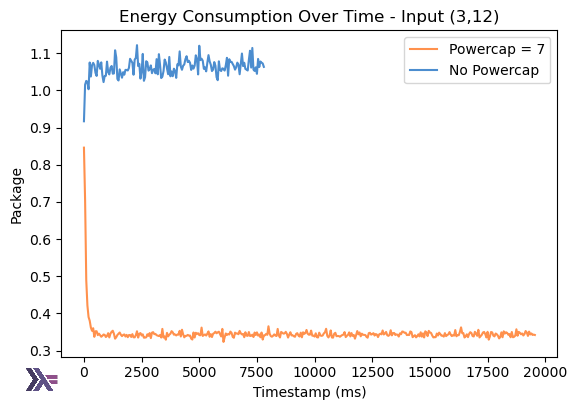

In [217]:
plot_language_energy(
    "Haskell",
    "312",
    "OverTimeMeasurements/Energy/energy_haskell_3_12"
)

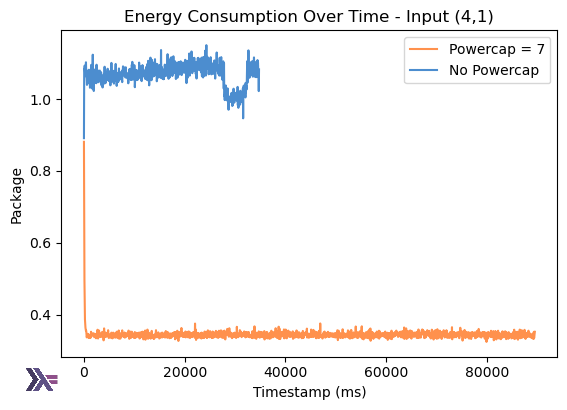

In [218]:
plot_language_energy(
    "Haskell",
    "41",
    "OverTimeMeasurements/Energy/energy_haskell_4_1"
)

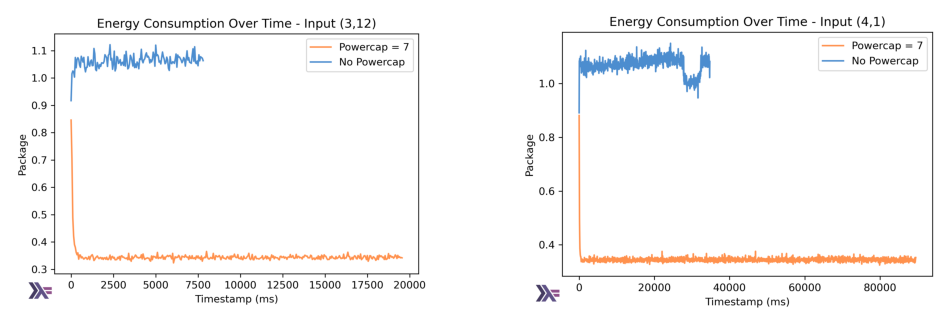

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

dir_ot = "graphics/OverTimeMeasurements/Energy/"

img1 = mpimg.imread(dir_ot + "energy_haskell_3_12.png")
img2 = mpimg.imread(dir_ot + "energy_haskell_4_1.png")

ax[0].imshow(img1)
ax[0].axis("off")
# ax[0].set_title("Powercap")


ax[1].imshow(img2)
ax[1].axis("off")
# ax[1].set_title("No Powercap")

plt.savefig(f"{dir_ot}energy_comparision_haskell.png", dpi=300, bbox_inches="tight")

plt.show()

## Energy Consumption Over Time - C

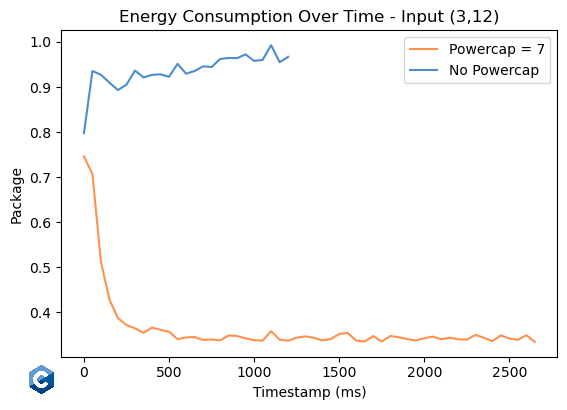

In [220]:
plot_language_energy(
    "C",
    "312",
    "OverTimeMeasurements/Energy/energy_C_3_12"
)

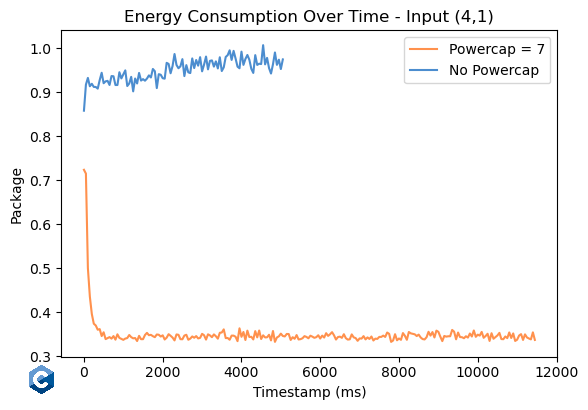

In [221]:
plot_language_energy(
    "C",
    "41",
    "OverTimeMeasurements/Energy/energy_C_4_1"
)

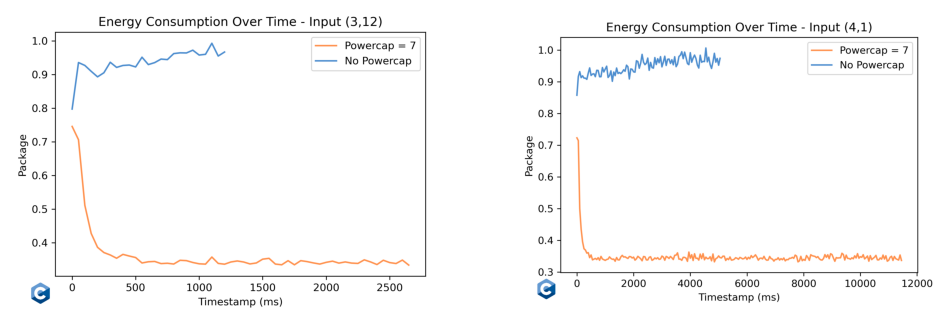

In [222]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

img1 = mpimg.imread(dir_ot + "energy_C_3_12.png")
img2 = mpimg.imread(dir_ot + "energy_C_4_1.png")

ax[0].imshow(img1)
ax[0].axis("off")
# ax[0].set_title("Powercap")


ax[1].imshow(img2)
ax[1].axis("off")
# ax[1].set_title("No Powercap")

plt.savefig(f"{dir_ot}energy_comparision_C.png", dpi=300, bbox_inches="tight")

plt.show()

## Energy Consumption Over Time - Python

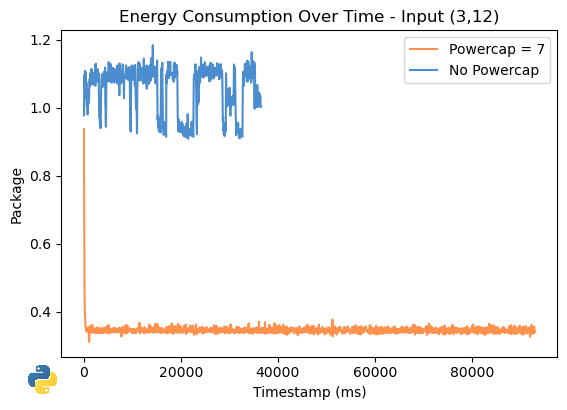

In [223]:
plot_language_energy(
    "Python",
    "312",
    "OverTimeMeasurements/Energy/energy_python_3_12"
)

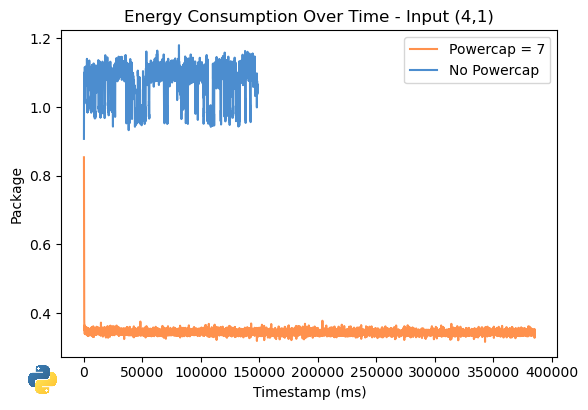

In [224]:
plot_language_energy(
    "Python",
    "41",
    "OverTimeMeasurements/Energy/energy_python_4_1"
)

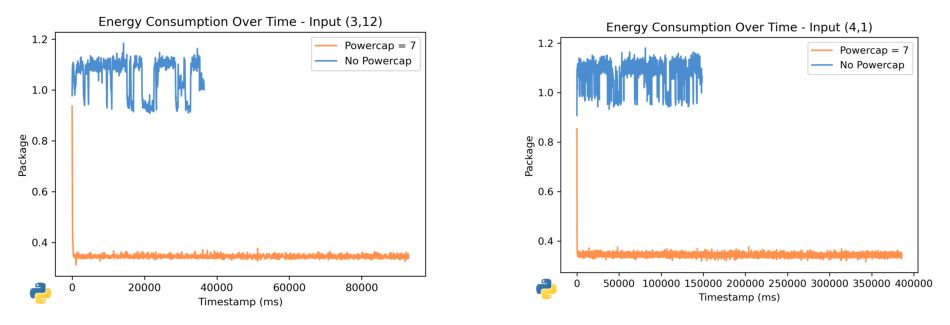

In [225]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

img1 = mpimg.imread(dir_ot + "energy_python_3_12.png")
img2 = mpimg.imread(dir_ot + "energy_python_4_1.png")

ax[0].imshow(img1)
ax[0].axis("off")
# ax[0].set_title("Powercap")


ax[1].imshow(img2)
ax[1].axis("off")
# ax[1].set_title("No Powercap")

plt.savefig(f"{dir_ot}energy_comparision_python.png", dpi=300, bbox_inches="tight")

plt.show()

## Energy Consumption Over Time - JavaScript

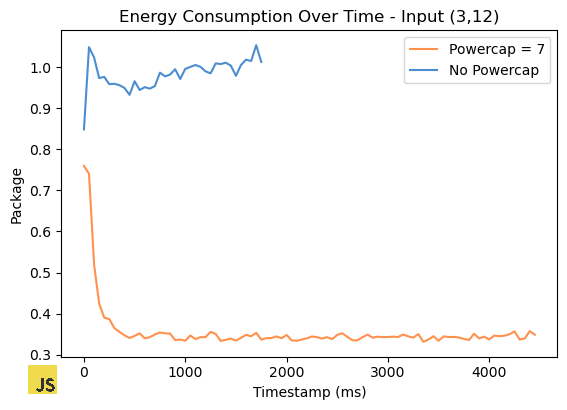

In [226]:
plot_language_energy(
    "JavaScript",
    "312",
    "OverTimeMeasurements/Energy/energy_javascript_3_12"
)

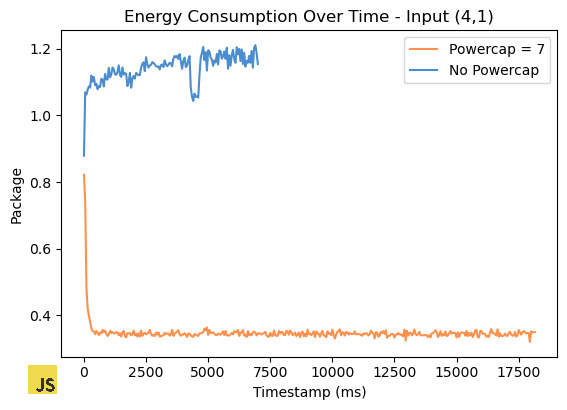

In [227]:
plot_language_energy(
    "JavaScript",
    "41",
    "OverTimeMeasurements/Energy/energy_javascript_4_1"
)

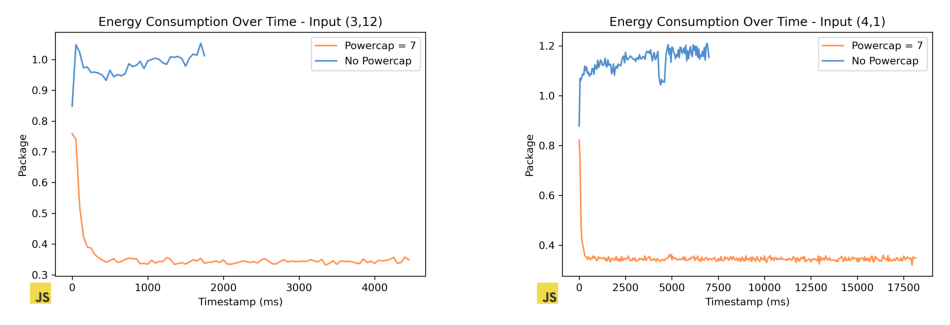

In [228]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

img1 = mpimg.imread(dir_ot + "energy_javascript_3_12.png")
img2 = mpimg.imread(dir_ot + "energy_javascript_4_1.png")

ax[0].imshow(img1)
ax[0].axis("off")
# ax[0].set_title("Powercap")


ax[1].imshow(img2)
ax[1].axis("off")
# ax[1].set_title("No Powercap")

plt.savefig(f"{dir_ot}energy_comparision_javascript.png", dpi=300, bbox_inches="tight")

plt.show()

## Temperature Over Time - Haskell

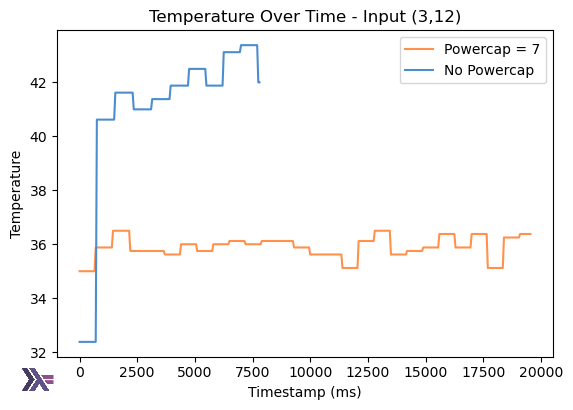

In [229]:
plot_language_temperature(
    "Haskell",
    "312",
    "OverTimeMeasurements/Temperature/temperature_haskell_3_12"
)

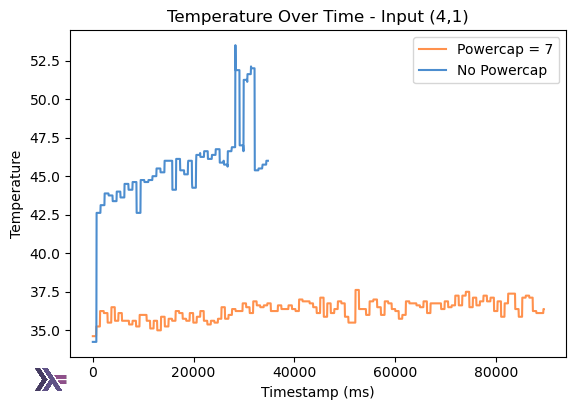

In [230]:
plot_language_temperature(
    "Haskell",
    "41",
    "OverTimeMeasurements/Temperature/temperature_haskell_4_1"
)

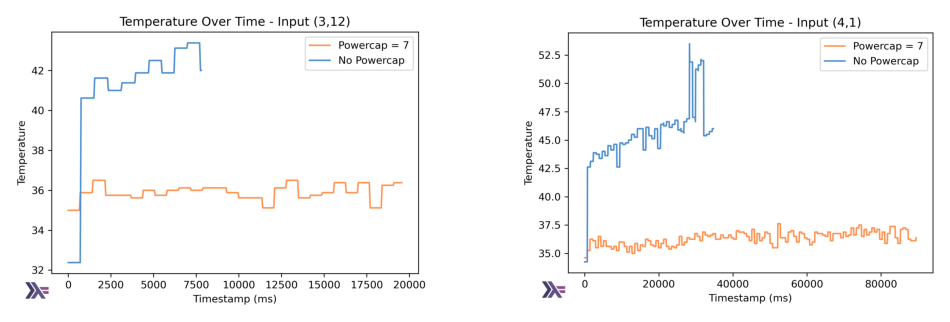

In [231]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

dir_ot = "graphics/OverTimeMeasurements/Temperature/"

img1 = mpimg.imread(dir_ot + "temperature_haskell_3_12.png")
img2 = mpimg.imread(dir_ot + "temperature_haskell_4_1.png")

ax[0].imshow(img1)
ax[0].axis("off")
# ax[0].set_title("Powercap")


ax[1].imshow(img2)
ax[1].axis("off")
# ax[1].set_title("No Powercap")

plt.savefig(f"{dir_ot}temperature_comparision_haskell.png", dpi=300, bbox_inches="tight")

plt.show()

## Temperature Over Time - C

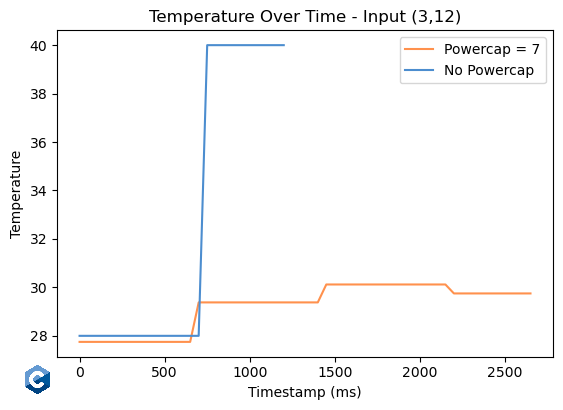

In [232]:
plot_language_temperature(
    "C",
    "312",
    "OverTimeMeasurements/Temperature/temperature_C_3_12"
)

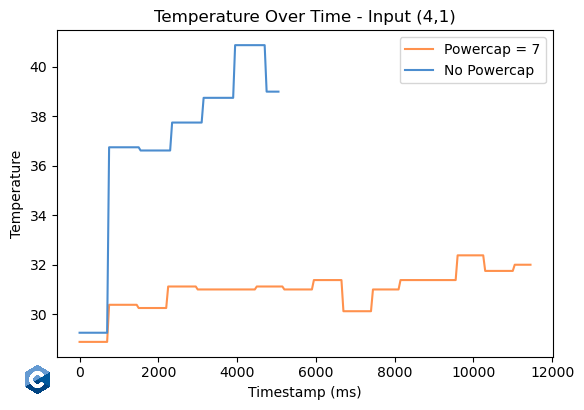

In [233]:
plot_language_temperature(
    "C",
    "41",
    "OverTimeMeasurements/Temperature/temperature_C_4_1"
)

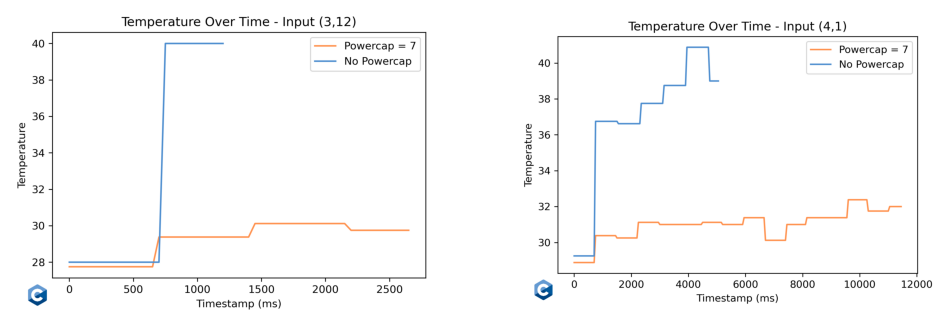

In [234]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

img1 = mpimg.imread(dir_ot + "temperature_C_3_12.png")
img2 = mpimg.imread(dir_ot + "temperature_C_4_1.png")

ax[0].imshow(img1)
ax[0].axis("off")
# ax[0].set_title("Powercap")


ax[1].imshow(img2)
ax[1].axis("off")
# ax[1].set_title("No Powercap")

plt.savefig(f"{dir_ot}temperature_comparision_C.png", dpi=300, bbox_inches="tight")

plt.show()

## Temperature Over Time - Python

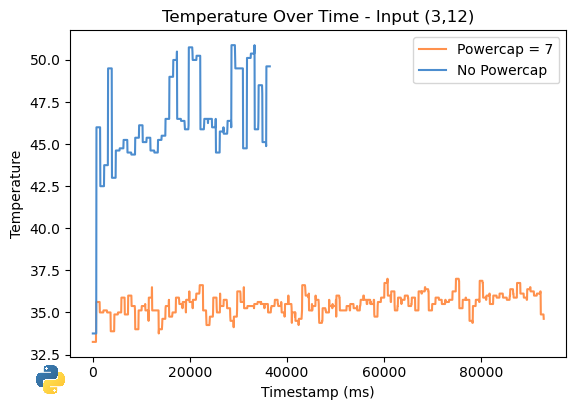

In [235]:
plot_language_temperature(
    "Python",
    "312",
    "OverTimeMeasurements/Temperature/temperature_python_3_12"
)

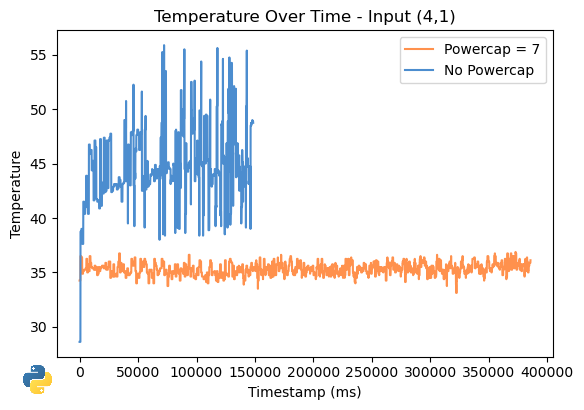

In [236]:
plot_language_temperature(
    "Python",
    "41",
    "OverTimeMeasurements/Temperature/temperature_python_4_1"
)

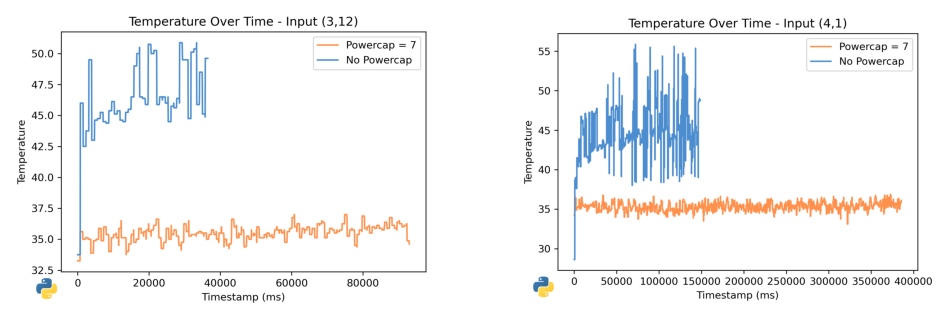

In [237]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

img1 = mpimg.imread(dir_ot + "temperature_python_3_12.png")
img2 = mpimg.imread(dir_ot + "temperature_python_4_1.png")

ax[0].imshow(img1)
ax[0].axis("off")
# ax[0].set_title("Powercap")


ax[1].imshow(img2)
ax[1].axis("off")
# ax[1].set_title("No Powercap")

plt.savefig(f"{dir_ot}temperature_comparision_python.png", dpi=300, bbox_inches="tight")

plt.show()

## Temperature Over Time - Javascript

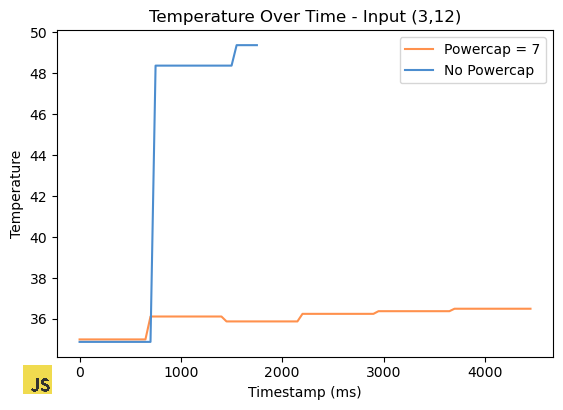

In [238]:
plot_language_temperature(
    "JavaScript",
    "312",
    "OverTimeMeasurements/Temperature/temperature_javascript_3_12"
)

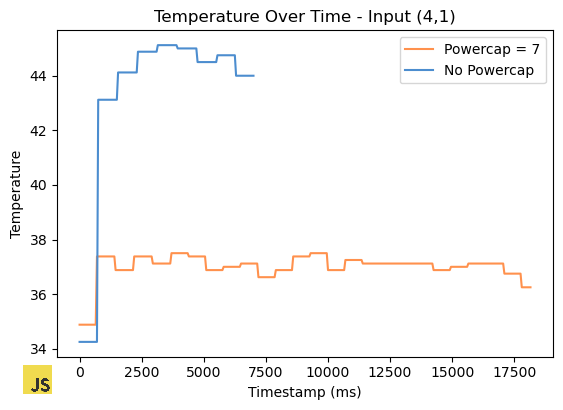

In [239]:
plot_language_temperature(
    "JavaScript",
    "41",
    "OverTimeMeasurements/Temperature/temperature_javascript_4_1"
)

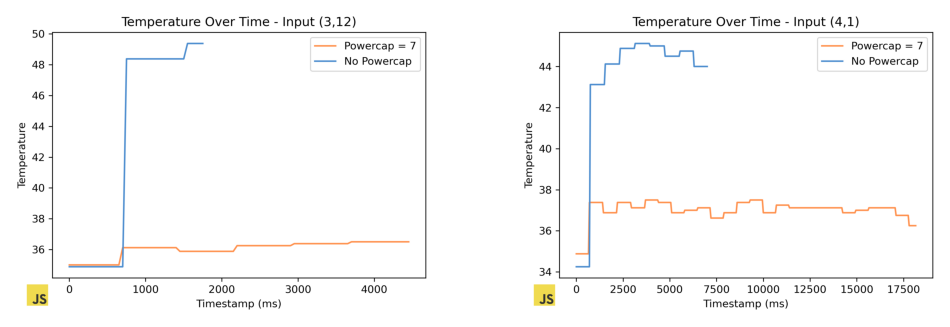

In [240]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

img1 = mpimg.imread(dir_ot + "temperature_javascript_3_12.png")
img2 = mpimg.imread(dir_ot + "temperature_javascript_4_1.png")

ax[0].imshow(img1)
ax[0].axis("off")
# ax[0].set_title("Powercap")


ax[1].imshow(img2)
ax[1].axis("off")
# ax[1].set_title("No Powercap")

plt.savefig(f"{dir_ot}temperature_comparision_javascript.png", dpi=300, bbox_inches="tight")

plt.show()